# Performance Check

One-shot performance + accuracy probe for the Cellpose detection pipeline. Run this once per machine (or after a `cellpose` / model upgrade) to pick the right `MODEL_TYPE` for `analysis.ipynb` without iterating.

**Sections:**
1. System info — platform, RAM, CPU/GPU, cellpose version.
2. Phase detection timing per model.
3. Nucleus detection timing per model.
4. Memory footprint after Cellpose runs.
5. Accuracy comparison on frame 0 (cell count + overlay).
6. Summary table with a recommendation.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../src")

from cell_analysis import (
    load_experiment, detect_cells_frame,
    profile_detection, profile_nucleus_detection,
    plot_detections,
)
from cell_analysis.segmentation import _resolve_gpu

## Configuration

Same paths and detection params as `analysis.ipynb`.

In [2]:
STACK_PATH = "../data/gradient_0011/Gradient-0011.zvi  Ch0.tif"
FLUOR_PATH = "../data/gradient_0011/Gradient-0011.zvi  Ch1-BG.tif"

DETECT_PARAMS = dict(
    diameter=32,
    min_area=300,
    min_circularity=0.7,
    min_contrast=1250,
    exclude_edges=True,
    gpu=True,
    resample=False,
)
NUCLEUS_DIAMETER = 25

# Models to compare. None = cellpose default (cpsam on v4).
# Default is cyto3 only because cpsam on CPU is 5-15 min/frame at this
# resolution. Add None to MODELS_TO_TEST if you have a real GPU or want
# to leave the kernel running.
MODELS_TO_TEST = ["cyto3"]

## 1. System info

If `GPU resolved` is `False` while `GPU requested` is `True`, you're on an Intel Mac and Cellpose 4.x is forced to CPU (see `_resolve_gpu` in `segmentation.py`).

In [3]:
import importlib.metadata
import os
import platform
import psutil

_gpu_req = DETECT_PARAMS.get("gpu", False)
_gpu_res = _resolve_gpu(_gpu_req)
_mem = psutil.virtual_memory()

print(f"Platform:        {platform.system()} {platform.machine()} ({platform.processor() or 'unknown CPU'})")
print(f"CPU cores:       {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical")
print(f"Total RAM:       {_mem.total / 1e9:.1f} GB  (available: {_mem.available / 1e9:.1f} GB)")
print(f"Cellpose:        {importlib.metadata.version('cellpose')}")
print(f"GPU requested:   {_gpu_req}")
print(f"GPU resolved:    {_gpu_res}")
if _gpu_req and not _gpu_res:
    print("  -> Cellpose will run on CPU. Expect minutes per frame on a 2019 Intel MBP.")

Platform:        Darwin arm64 (arm)
CPU cores:       16 physical / 16 logical
Total RAM:       137.4 GB  (available: 74.6 GB)
Cellpose:        4.1.1
GPU requested:   True
GPU resolved:    True


## Load stack

In [4]:
phase_stack, fluor_stack = load_experiment(STACK_PATH, FLUOR_PATH)
print(f"Phase stack: {phase_stack.shape}, {phase_stack.dtype}")
print(f"Fluor stack: {fluor_stack.shape}, {fluor_stack.dtype}")

Phase stack: (25, 1040, 1388) (frames=25, size=1388x1040, dtype=uint16)
Fluorescence stack: (25, 1040, 1388), dtype=uint16
Phase stack: (25, 1040, 1388), uint16
Fluor stack: (25, 1040, 1388), uint16


## 2. Phase detection timing

Per model: load once, time one inference on frame 0, project totals.

**Expected times on a 2019 Intel MBP (CPU only):**
- `cyto3`: ~5-10 s/frame
- `cpsam` (the cellpose 4.x default): ~5-15 min/frame, plus a one-time ~2 GB download on first use

In [5]:
phase_timings = {}
for model_type in MODELS_TO_TEST:
    label = model_type or "default"
    print(f"\n--- {label} ---")
    phase_timings[label] = profile_detection(
        phase_stack, model_type=model_type, nucleus_pass=False, **DETECT_PARAMS
    )


--- default ---
  Inference: 5.7 s/frame  (model_type=default)
  Phase pass over 25 frames: ~2.4 min

--- cyto3 ---
  Inference: 5.6 s/frame  (model_type=cyto3)
  Phase pass over 25 frames: ~2.4 min


## 3. Nucleus detection timing

Confirms whether the nucleus pass is roughly the same cost as phase. If nucleus inference is much cheaper, the headline estimate from §2 is conservative.

In [6]:
nucleus_timings = {}
for model_type in MODELS_TO_TEST:
    label = model_type or "default"
    print(f"\n--- {label} ---")
    nucleus_timings[label] = profile_nucleus_detection(
        fluor_stack,
        model_type=model_type,
        diameter=NUCLEUS_DIAMETER,
        gpu=DETECT_PARAMS.get("gpu", False),
        resample=DETECT_PARAMS.get("resample", False),
    )


--- default ---
  Nucleus inference: 7.1 s/frame  (model_type=default)
  Nucleus pass over 25 frames: ~3.0 min

--- cyto3 ---
  Nucleus inference: 7.2 s/frame  (model_type=cyto3)
  Nucleus pass over 25 frames: ~3.0 min


## 4. Memory footprint

Cellpose 4.x (SAM backbone) is ~2 GB resident per model. If this process is using more than ~75% of total RAM, you're likely swap-thrashing — that's the most common cause of *hours-per-frame* slowdowns on 16 GB Intel Macs.

In [7]:
_proc = psutil.Process(os.getpid())
_rss = _proc.memory_info().rss
_total = psutil.virtual_memory().total
_frac = _rss / _total
print(f"Process RSS:    {_rss / 1e9:5.1f} GB")
print(f"Total RAM:      {_total / 1e9:5.1f} GB")
print(f"Process share:  {_frac * 100:5.1f}%")
if _frac > 0.75:
    print("  WARN: high memory pressure -> likely swap. Close other apps or use a bigger machine.")

Process RSS:      1.7 GB
Total RAM:      137.4 GB
Process share:    1.2%


## 5. Accuracy comparison (frame 0)

Cell count + overlay per model. If cell counts diverge, retune `min_contrast`/`diameter` for the faster model before switching.

default: 371 cells
cyto3: 371 cells


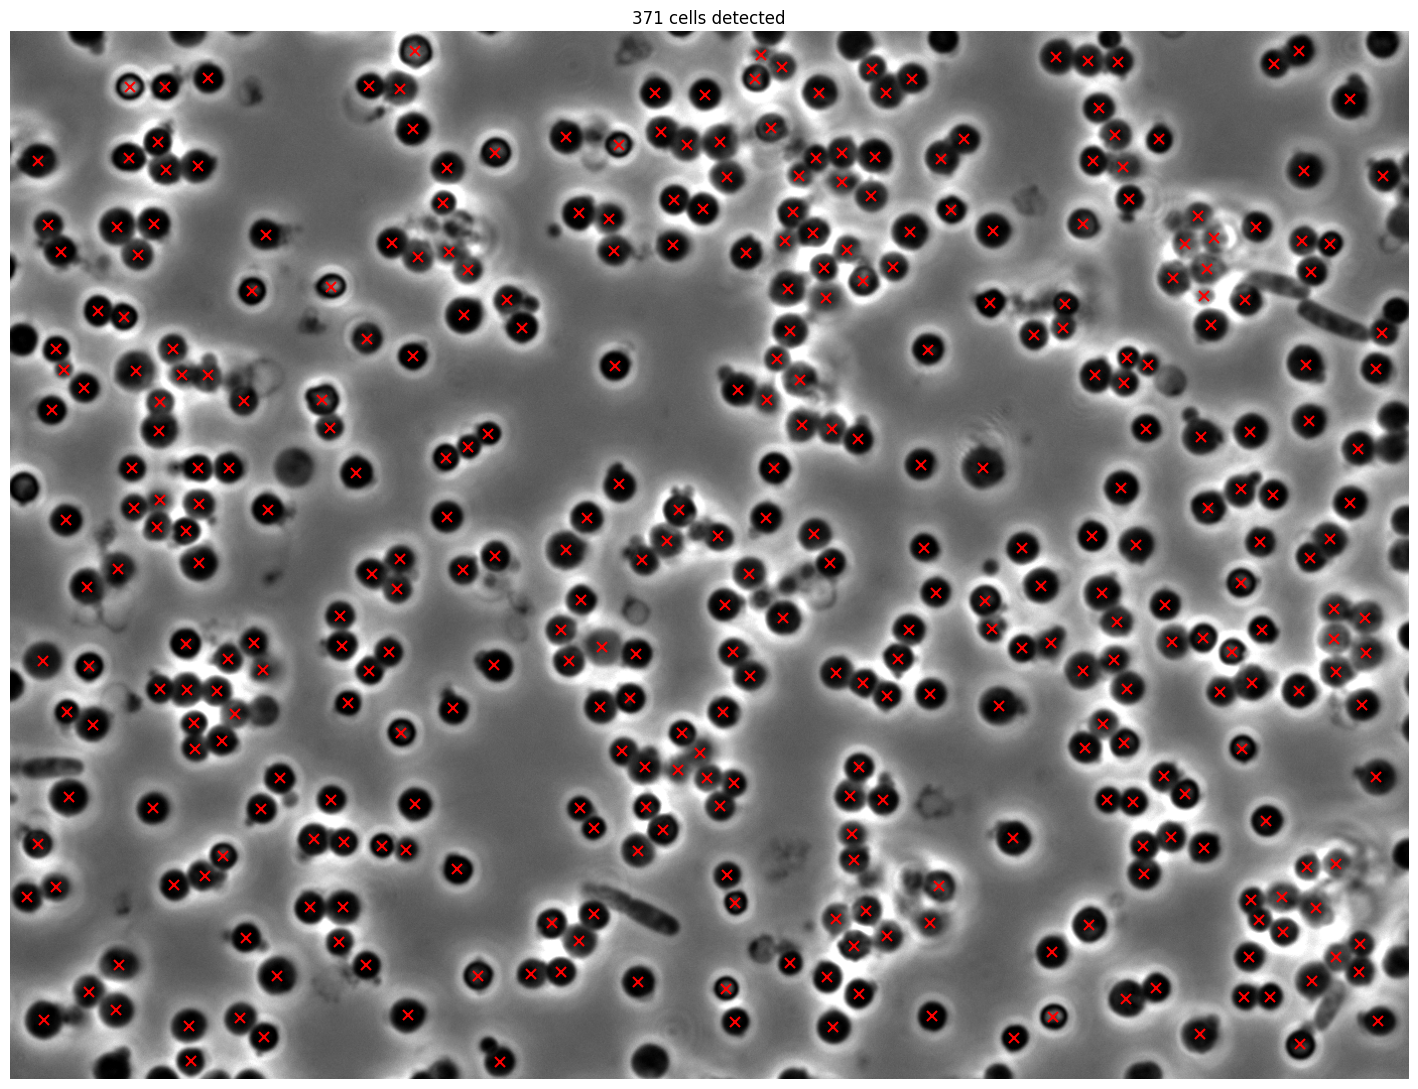

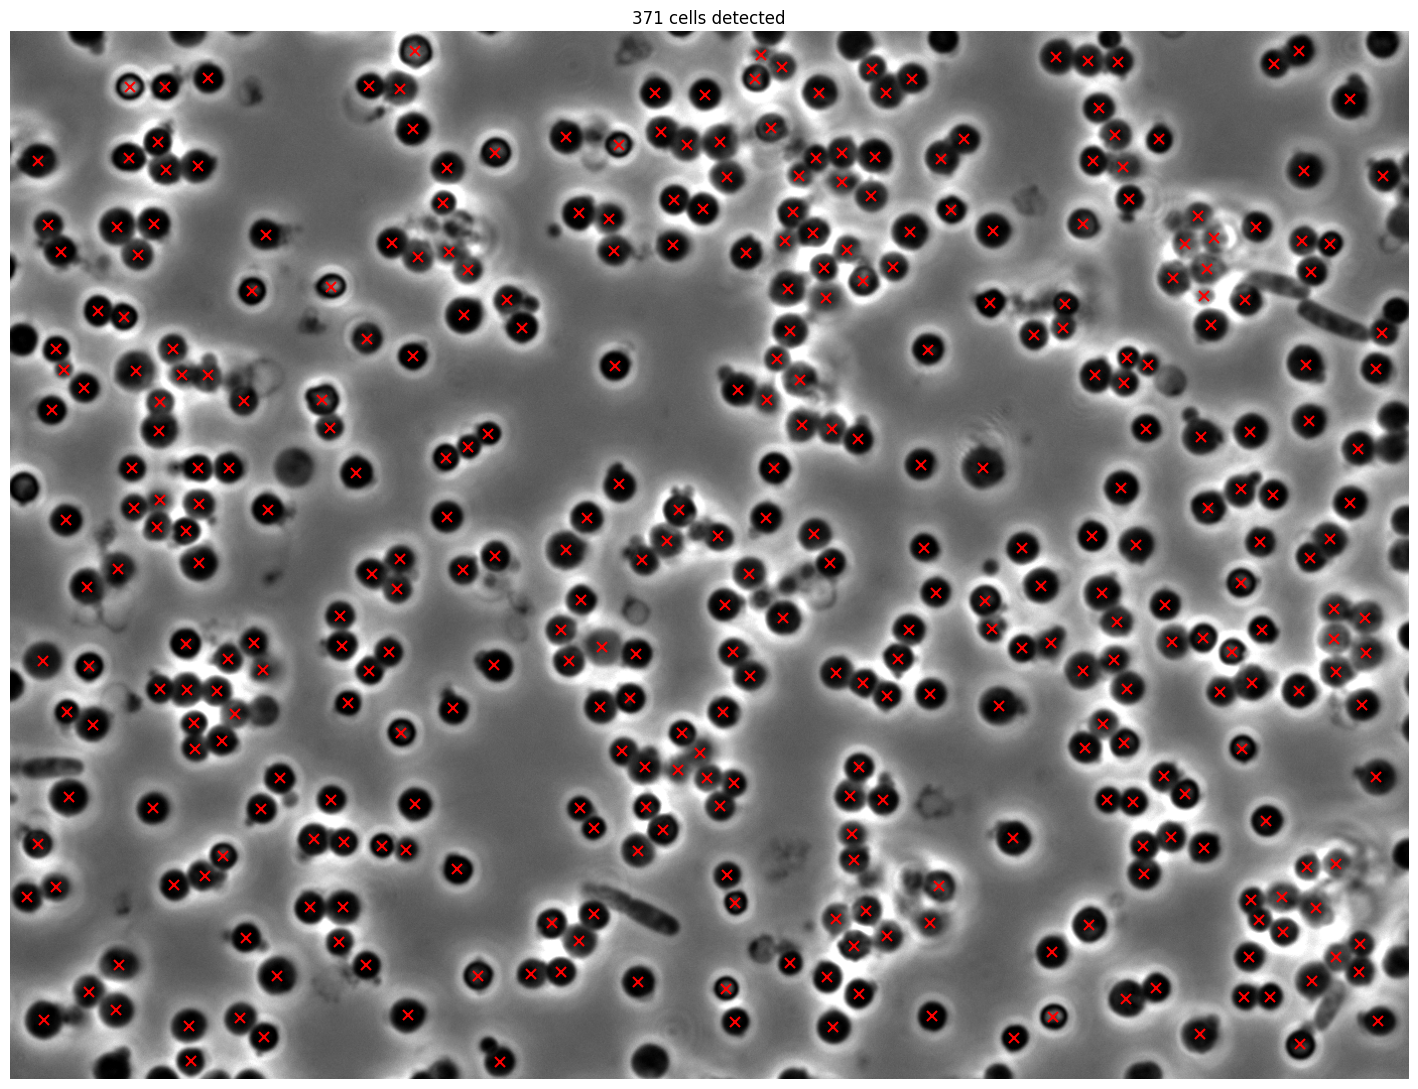

In [8]:
counts = {}
for model_type in MODELS_TO_TEST:
    label = model_type or "default"
    centroids, _ = detect_cells_frame(
        phase_stack[0], model_type=model_type, **DETECT_PARAMS
    )
    counts[label] = len(centroids)
    print(f"{label}: {len(centroids)} cells")
    plot_detections(phase_stack[0], centroids)

## 6. Summary

Pick the fastest model whose cell count is within a few percent of the baseline. Set `MODEL_TYPE` to that name in `analysis.ipynb` or in your `configs/*.yaml`.

In [9]:
baseline = list(counts)[0]
print(f"{'model':>10s}  {'phase s/f':>10s}  {'nucl s/f':>10s}  {'total min':>10s}  {'cells':>6s}  {'delta':>6s}")
print("-" * 64)
for label in counts:
    p = phase_timings[label]["sec_per_frame"]
    n = nucleus_timings[label]["sec_per_frame"]
    T = phase_timings[label]["n_frames"]
    total = (p + n) * T / 60
    delta = counts[label] - counts[baseline]
    print(
        f"{label:>10s}  {p:10.1f}  {n:10.1f}  {total:10.1f}  "
        f"{counts[label]:6d}  {delta:+6d}"
    )

     model   phase s/f    nucl s/f   total min   cells   delta
----------------------------------------------------------------
   default         5.7         7.1         5.3     371      +0
     cyto3         5.6         7.2         5.3     371      +0


## 7. Shareable report

Writes a compact markdown summary to `results/perf_check.md` (and renders it below). You can email the file, paste the rendered block into an issue or chat, or hand it to whoever's tuning the pipeline.

In [10]:
import datetime
from IPython.display import Markdown

_baseline = list(counts)[0]
_rows = []
for label in counts:
    p = phase_timings[label]["sec_per_frame"]
    n = nucleus_timings[label]["sec_per_frame"]
    T = phase_timings[label]["n_frames"]
    total = (p + n) * T / 60
    delta = counts[label] - counts[_baseline]
    _rows.append(
        f"| `{label}` | {p:.1f} | {n:.1f} | {total:.1f} | {counts[label]} | {delta:+d} |"
    )

_report = f"""# Perf check report

- **Host:** `{platform.node()}`
- **Date:** {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
- **Platform:** {platform.system()} {platform.machine()}
- **CPU:** {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical
- **RAM:** {_mem.total / 1e9:.1f} GB total ({_mem.available / 1e9:.1f} GB free at start)
- **Cellpose:** {importlib.metadata.version('cellpose')}
- **GPU requested / resolved:** {_gpu_req} / {_gpu_res}
- **Stack:** {phase_stack.shape} {phase_stack.dtype}
- **Process RSS after Cellpose:** {_rss / 1e9:.1f} GB ({_frac * 100:.0f}% of total)

| model | phase s/f | nucleus s/f | total min | cells (frame 0) | delta vs baseline |
|-------|-----------|-------------|-----------|-----------------|-------------------|
""" + "\n".join(_rows) + "\n"

_report_path = Path("../results/perf_check.md")
_report_path.parent.mkdir(parents=True, exist_ok=True)
_report_path.write_text(_report, encoding="utf-8")
print(f"Saved: {_report_path.resolve()}")
display(Markdown(_report))

Saved: /Users/vvetshte/Projects/temp/experiments_image/results/perf_check.md


# Perf check report

- **Host:** `naamasim-mobl.ger.corp.intel.com`
- **Date:** 2026-06-06 10:46
- **Platform:** Darwin arm64
- **CPU:** 16 physical / 16 logical
- **RAM:** 137.4 GB total (74.6 GB free at start)
- **Cellpose:** 4.1.1
- **GPU requested / resolved:** True / True
- **Stack:** (25, 1040, 1388) uint16
- **Process RSS after Cellpose:** 1.7 GB (1% of total)

| model | phase s/f | nucleus s/f | total min | cells (frame 0) | delta vs baseline |
|-------|-----------|-------------|-----------|-----------------|-------------------|
| `default` | 5.7 | 7.1 | 5.3 | 371 | +0 |
| `cyto3` | 5.6 | 7.2 | 5.3 | 371 | +0 |
